In [1]:
import os
import sys
import pandas as pd
cwd = os.getcwd()
project_root = os.path.abspath(os.path.join(cwd, ".."))
sys.path.append(os.path.dirname(project_root))
from modeling.neuralmodeling.exp.Experiments import Experiment
from modeling.statmodeling.sarimax import SARIMAX

No cache found. Training SARIMAX...


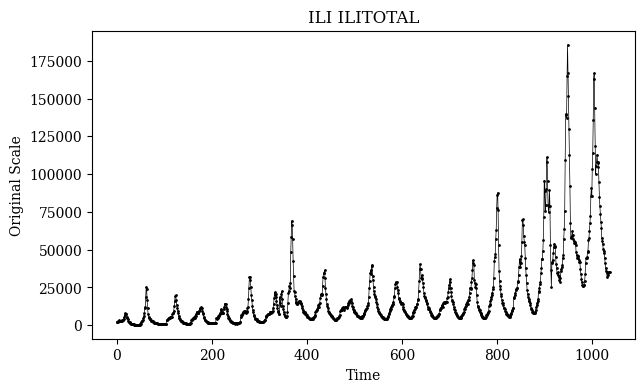

Rolling forecast:   0%|          | 0/196 [00:03<?, ?it/s]


KeyboardInterrupt: 

In [5]:
import pickle
from pathlib import Path
import numpy as np
from util.tools import dotdict

# ============================================================
# Config
# ============================================================
sarimax_args = dotdict()

sarimax_args["data_path"] = "../../datasets/ili/national_illness_24.csv"
sarimax_args["dataset"] = "ILI"
sarimax_args["date_col"] = "date"
sarimax_args["target"] = "ILITOTAL"
sarimax_args["training_ratio"] = 80
sarimax_args["normalization"] = "log"

sarimax_args["p"] = 1
sarimax_args["d"] = 0
sarimax_args["q"] = 1
sarimax_args["P"] = 1
sarimax_args["D"] = 1
sarimax_args["Q"] = 1
sarimax_args["s"] = 52

sarimax_args["forecast_type"] = "point"
sarimax_args["plot_scope_scale"] = "test_original"
sarimax_args["plot_eda"] = False
sarimax_args["qof_calculation_mode"] = "single_horizon"
sarimax_args["trend"] = "n"
sarimax_args["horizons"] = list(range(1, 13))

sarimax_args["rc"] = 13

sarimax_args["fit_method"] = "lbfgs"
sarimax_args["optimizer_maxiter"] = 100
sarimax_args["same_n_samples"] = True
sarimax_args["features"] = "S"
sarimax_args["skip_insample"] = None
sarimax_args["modeling_approach"] = "joint"
sarimax_args["debugging"] = False

sarimax_args["clip_dates"] = True
sarimax_args["start_date"] = "2020-04-13"
sarimax_args["end_date"] = "2022-04-04"

sarimax_args["qof_to_display"] = [
    "h",
    "n",
    "MSE Normalized",
    "MAE Normalized",
    "MAE Original",
    "sMAPE Original",
]

sarimax_args["use_fourier_exog"] = True
sarimax_args["fourier_order"] = 2

sarimax_args["use_bump_exog"] = True
sarimax_args["bump_mu"] = 7.0
sarimax_args["bump_s"] = 2.0
sarimax_args["bump_nu"] = 4.0

sarimax_args["use_trend_exog"] = True
sarimax_args["include_provider_exog"] = False
sarimax_args["include_patient_exog"] = False


# ============================================================
# Cache paths
# ============================================================
cache_dir = Path("./cache/sarimax")
cache_dir.mkdir(parents=True, exist_ok=True)

cache_tag = (
    f"{sarimax_args['dataset']}_"
    f"{sarimax_args['target']}_"
    f"{sarimax_args['start_date']}_{sarimax_args['end_date']}_"
    f"p{sarimax_args['p']}_d{sarimax_args['d']}_q{sarimax_args['q']}_"
    f"P{sarimax_args['P']}_D{sarimax_args['D']}_Q{sarimax_args['Q']}_s{sarimax_args['s']}_"
    f"rc{sarimax_args['rc']}_"
    f"fourier{int(sarimax_args['use_fourier_exog'])}_k{sarimax_args['fourier_order']}_"
    f"bump{int(sarimax_args['use_bump_exog'])}_"
    f"trend{int(sarimax_args['use_trend_exog'])}"
)

model_cache_path = cache_dir / f"{cache_tag}_model.pkl"
forecast_cache_path = cache_dir / f"{cache_tag}_forecast.npy"


# ============================================================
# Load if exists, else train and save
# ============================================================
if model_cache_path.exists() and forecast_cache_path.exists():
    print(f"Loading cached SARIMAX artifacts from:\n- {model_cache_path}\n- {forecast_cache_path}")

    with open(model_cache_path, "rb") as f:
        sarimax_model = pickle.load(f)

    sarimax_forecast_tensor = np.load(forecast_cache_path)

else:
    print("No cache found. Training SARIMAX...")
    sarimax_model = SARIMAX(sarimax_args)
    sarimax_forecast_tensor = sarimax_model.trainNtest()

    with open(model_cache_path, "wb") as f:
        pickle.dump(sarimax_model, f)

    np.save(forecast_cache_path, sarimax_forecast_tensor)

    print(f"Saved SARIMAX artifacts to:\n- {model_cache_path}\n- {forecast_cache_path}")

In [ ]:
sarimax_model = SARIMAX(sarimax_args)
sarimax_forecast_tensor = sarimax_model.trainNtest()

In [ ]:
def invert_diagonal_forecast_tensor(forecast_tensor: np.ndarray) -> np.ndarray:
    """
    Convert diagonalized rolling forecast tensor back into the per-origin forecast matrix.

    Input:
        forecast_tensor shape = [N, H, C]

    Output:
        origin_matrix shape = [N - H + 1, H]
        where row j contains the full H-step forecast issued at rolling origin j.
    """
    if forecast_tensor.ndim != 3 or forecast_tensor.shape[-1] != 1:
        raise ValueError(f"Expected forecast_tensor shape [N, H, 1], got {forecast_tensor.shape}")

    N, H, _ = forecast_tensor.shape
    n_origins = N - H + 1

    origin_matrix = np.zeros((n_origins, H), dtype=float)
    for j in range(n_origins):
        for h in range(H):
            origin_matrix[j, h] = forecast_tensor[j + h, h, 0]

    return origin_matrix


def build_one_step_series_from_origin_matrix(
    train_series: np.ndarray,
    test_series: np.ndarray,
    origin_matrix: np.ndarray,
) -> np.ndarray:
    """
    Build a full-length one-step-ahead baseline series aligned with y.

    For training portion:
        currently uses naive carry-forward placeholder equal to actual y.
        This avoids leakage only as a temporary bootstrap, but it is NOT ideal.

    For test portion:
        uses true rolling one-step-ahead SARIMAX forecasts from origin_matrix[:, 0].

    Note:
        You should later replace the training-side placeholder with true rolling
        one-step-ahead training predictions if you expose that from SARIMAX.
    """
    full_len = len(train_series) + len(test_series)
    baseline = np.full(full_len, np.nan, dtype=float)

    # temporary placeholder on train side
    baseline[: len(train_series)] = train_series

    # true rolling 1-step forecasts on test side
    baseline[len(train_series) : len(train_series) + len(origin_matrix)] = origin_matrix[:, 0]

    return baseline


def make_residual_csv(
    sarimax_model,
    sarimax_forecast_tensor: np.ndarray,
    out_path: str,
    residual_col: str = "ILITOTAL_RESIDUAL",
) -> pd.DataFrame:
    """
    Build a residual CSV from the existing SARIMAX run.

    This version is intentionally conservative and aligned to your current codebase.
    """
    y_df = sarimax_model.data.copy().reset_index(drop=True)
    target_col = sarimax_model.target.lower()

    if target_col not in y_df.columns:
        raise ValueError(f"Target column '{target_col}' not found in SARIMAX loaded data.")

    y = y_df[target_col].to_numpy(dtype=float)

    train_size = sarimax_model.train_size
    test_size = sarimax_model.test_size

    origin_matrix = invert_diagonal_forecast_tensor(sarimax_forecast_tensor)

    y_train = y[:train_size]
    y_test = y[train_size : train_size + test_size]

    one_step_baseline = build_one_step_series_from_origin_matrix(
        train_series=y_train,
        test_series=y_test,
        origin_matrix=origin_matrix,
    )

    residual = y - one_step_baseline

    if hasattr(sarimax_model, "dates") and sarimax_model.dates is not None:
        dates = pd.to_datetime(pd.Series(sarimax_model.dates)).reset_index(drop=True)
    else:
        raise ValueError("SARIMAX model does not expose aligned dates.")

    df = pd.DataFrame({
        "date": dates,
        target_col.upper(): y,
        "SARIMAX_BASELINE_1STEP": one_step_baseline,
        residual_col: residual,
    })

    df.to_csv(out_path, index=False)
    return df

In [ ]:
residual_csv_path = "../../datasets/ili/national_illness_24_residual_sarimax.csv"

residual_df = make_residual_csv(
    sarimax_model=sarimax_model,
    sarimax_forecast_tensor=sarimax_forecast_tensor,
    out_path=residual_csv_path,
    residual_col="ILITOTAL_RESIDUAL",
)

residual_df.head()

In [ ]:
hybrid_args = dotdict()

hybrid_args.cwd = cwd
hybrid_args.model_name = "ResidualTCN"
hybrid_args.random_seed = 10

hybrid_args.seq_len = 60
hybrid_args.label_len = 0
hybrid_args.horizons = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
hybrid_args.modeling_approach = "joint"

hybrid_args.dataset = "ILI_RESIDUAL"
hybrid_args.data = "ILI_RESIDUAL"
hybrid_args.target = "ILITOTAL_RESIDUAL"
hybrid_args.data_path = residual_csv_path

hybrid_args.features = "S"
hybrid_args.enc_in = 1
hybrid_args.dec_in = 1
hybrid_args.c_out = 1

hybrid_args.learning_rate = 0.001
hybrid_args.is_training = 1
hybrid_args.model_id = "ILI_RESIDUAL"

hybrid_args.dropout = 0.2
hybrid_args.fc_dropout = 0.0
hybrid_args.head_dropout = 0.0

hybrid_args.train_epochs = 100
hybrid_args.patience = 10
hybrid_args.batch_size = 16
hybrid_args.loss = "mse"
hybrid_args.lradj = "type2"
hybrid_args.use_amp = False
hybrid_args.gpu = 0
hybrid_args.use_multi_gpu = True
hybrid_args.devices = "0"
hybrid_args.use_gpu = True
hybrid_args.num_workers = 0
hybrid_args.freq = "h"

hybrid_args.pct_start = 0.3
hybrid_args.plot_eda = False
hybrid_args.normalization = "log"
hybrid_args.forecast_type = "point"
hybrid_args.plot_scope_scale = "test_original"
hybrid_args.qof_calculation_mode = "single_horizon"
hybrid_args.same_n_samples = True

hybrid_args.skip_insample = None
hybrid_args.training_ratio = 0.8
hybrid_args.debugging = True
hybrid_args.plot_losses = True

hybrid_args.clip_dates = True
hybrid_args.start_date = "2020-04-13"
hybrid_args.end_date = "2022-04-04"

hybrid_args.qof_to_display = [
    "h",
    "n",
    "MSE Normalized",
    "MAE Normalized",
    "MAE Original",
    "sMAPE Original",
]

# TCN-specific
hybrid_args.tcn_hidden = 64
hybrid_args.tcn_levels = 5
hybrid_args.tcn_kernel_size = 3
hybrid_args.tcn_dropout = 0.2

# compatibility placeholders for Experiment setting string / shared framework
hybrid_args.e_layers = 1
hybrid_args.d_layers = 1
hybrid_args.d_model = 64
hybrid_args.n_heads = 1
hybrid_args.d_ff = 64

# compatibility placeholders for framework fields used elsewhere
hybrid_args.factor = 1
hybrid_args.distil = False
hybrid_args.activation = "gelu"
hybrid_args.embed_type = 0
hybrid_args.revin = False
hybrid_args.subtract_last = False
hybrid_args.learn_scale = False
hybrid_args.plot_residuals = None
hybrid_args.residual_lag = 20
hybrid_args.cycle = 52
hybrid_args.model_type = "tcn"

hybrid_args.use_tf = False
hybrid_args.tf_ratio = 0.0

Exp_hybrid = Experiment(hybrid_args)
residual_forecast_tensor = Exp_hybrid.trainNtest()

In [ ]:
if sarimax_forecast_tensor.shape != residual_forecast_tensor.shape:
    raise ValueError(
        f"Shape mismatch: SARIMAX {sarimax_forecast_tensor.shape} vs residual {residual_forecast_tensor.shape}"
    )

hybrid_forecast_tensor = sarimax_forecast_tensor + residual_forecast_tensor
hybrid_forecast_tensor.shape